In [10]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import json
import cv2
from sklearn.metrics import confusion_matrix, classification_report


In [51]:
import os
from PIL import Image

dataset_paths = [
    "C:\\Users\\Rahul Chauhan\\OneDrive\\Desktop\\Project Dataset Wheat\\data\\train",
    "C:\\Users\\Rahul Chauhan\\OneDrive\\Desktop\\Project Dataset Wheat\\data\\test"
]

for dataset_path in dataset_paths:
    print(f"Converting PNG to JPG in: {dataset_path}")
    for folder in os.listdir(dataset_path):
        folder_path = os.path.join(dataset_path, folder)
        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file)
                file_ext = os.path.splitext(file)[1].lower()
                
                if file_ext == ".png":
                    try:
                        img = Image.open(file_path).convert("RGB")
                        new_file_path = os.path.splitext(file_path)[0] + ".jpg"
                        img.save(new_file_path, "JPEG")
                        os.remove(file_path)  # Remove old PNG file
                        print(f"Converted: {file_path} → {new_file_path}")
                    except Exception as e:
                        print(f"Error converting {file_path}: {e}")


Converting PNG to JPG in: C:\Users\Rahul Chauhan\OneDrive\Desktop\Project Dataset Wheat\data\train
Converting PNG to JPG in: C:\Users\Rahul Chauhan\OneDrive\Desktop\Project Dataset Wheat\data\test


In [11]:
train_path = "C:\\Users\\Rahul Chauhan\\OneDrive\\Desktop\\ALL\\Project Dataset Wheat\\data\\train"

training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True
)


Found 13104 files belonging to 15 classes.


In [12]:
test_path = "C:\\Users\\Rahul Chauhan\\OneDrive\\Desktop\\ALL\\Project Dataset Wheat\\data\\test" 

test_set = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False  # Do not shuffle test data
)


Found 748 files belonging to 15 classes.


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input

cnn = Sequential()

cnn.add(Input(shape=(128, 128, 3)))

cnn.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=64, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=128, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=256, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=512, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Flatten())
cnn.add(Dense(units=1500, activation='relu'))
cnn.add(Dropout(0.4)) 

cnn.add(Dense(units=15, activation='softmax'))

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [14]:
cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()

training_history = cnn.fit(training_set, validation_data=test_set, epochs=10)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 15)                  │          22,515 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,808,239 (29.79 MB)

 Trainable params: 7,808,239 (29.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 247s 595ms/step - accuracy: 0.2000 - loss: 2.5230 - val_accuracy: 0.2901 - val_loss: 2.2534
Epoch 2/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 240s 584ms/step - accuracy: 0.4177 - loss: 1.8306 - val_accuracy: 0.4091 - val_loss: 1.7674
Epoch 3/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 240s 586ms/step - accuracy: 0.5058 - loss: 1.5305 - val_accuracy: 0.4933 - val_loss: 1.5490
Epoch 4/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 245s 596ms/step - accuracy: 0.5731 - loss: 1.3301 - val_accuracy: 0.5000 - val_loss: 1.5169
Epoch 5/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 240s 585ms/step - accuracy: 0.6400 - loss: 1.1149 - val_accuracy: 0.6337 - val_loss: 1.1359
Epoch 6/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 240s 585ms/step - accuracy: 0.6896 - loss: 0.9405 - val_accuracy: 0.7299 - val_loss: 0.7852
Epoch 7/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 240s 584ms/step - accuracy: 0.7574 - loss: 0.7192 - val_accuracy: 0.7674 - val_loss: 0.6956
Epoch 8/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 240s 586ms/step - accuracy: 0.8097 -

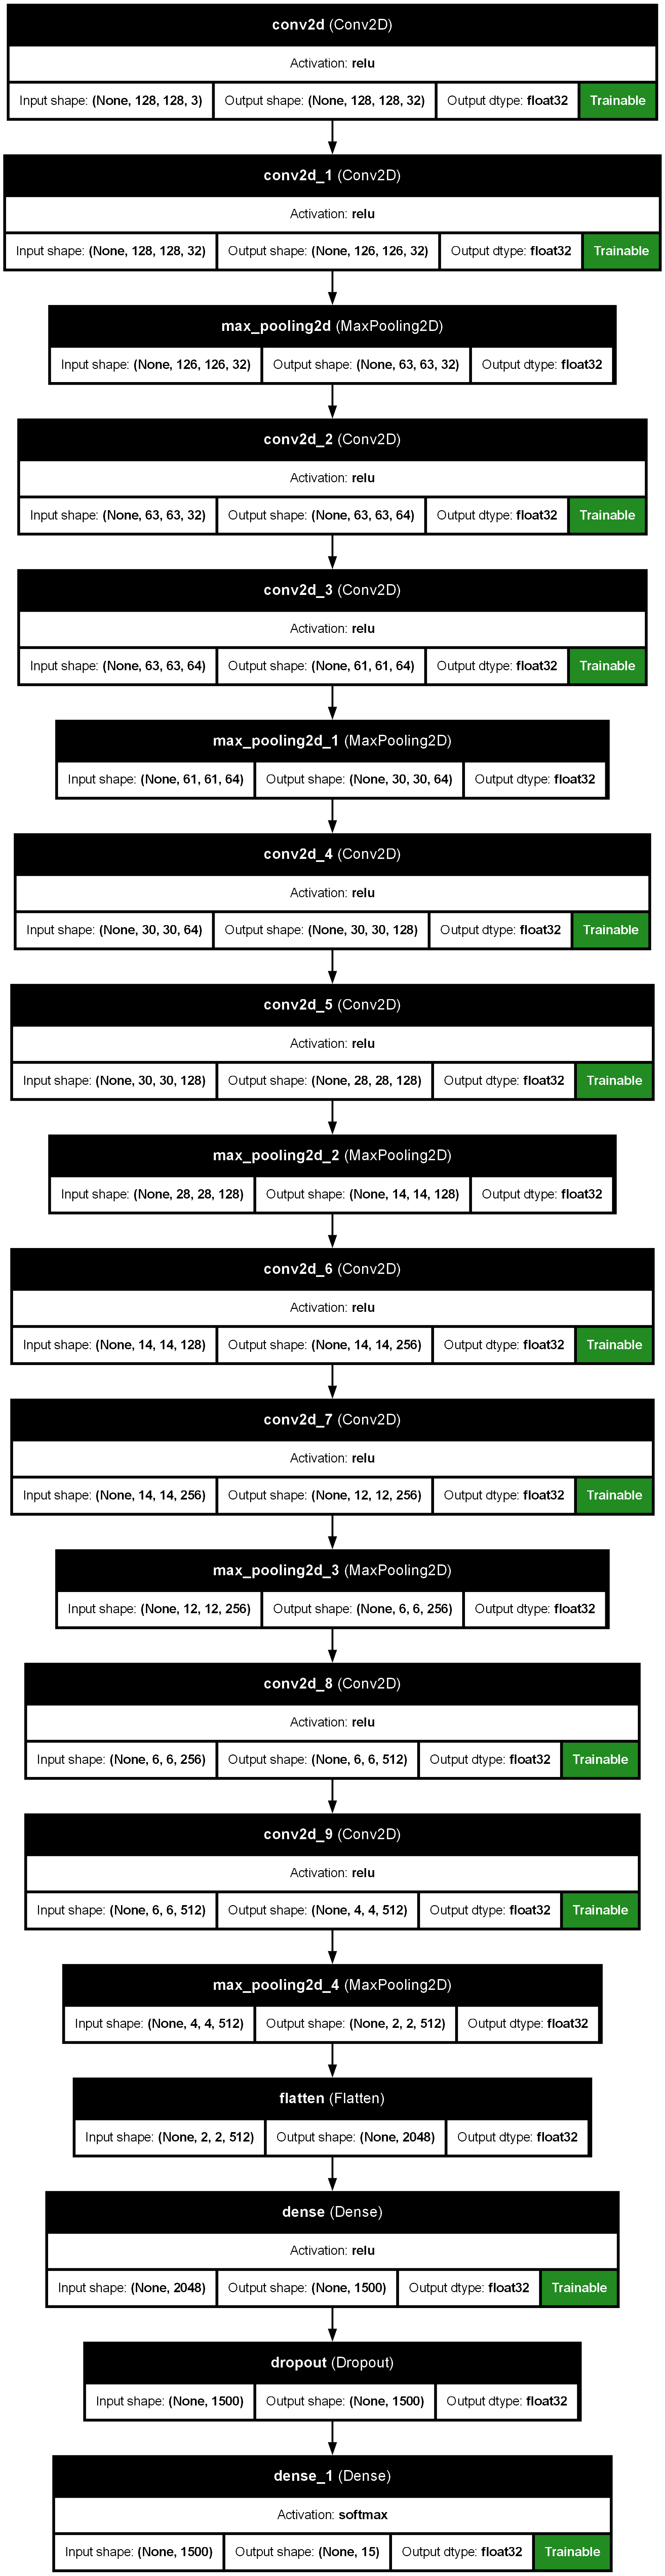

In [5]:
from keras.utils import plot_model
plot_model(cnn, to_file='model.png', 
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=False,
    dpi=200,
    show_layer_activations=True,
    show_trainable=True)

In [17]:

train_loss, train_acc = cnn.evaluate(training_set)
print(f"Training Accuracy: {train_acc}")

test_loss, test_acc = cnn.evaluate(test_set)
print(f"Test Accuracy: {test_acc}")


410/410 ━━━━━━━━━━━━━━━━━━━━ 64s 156ms/step - accuracy: 0.9014 - loss: 0.3050
Training Accuracy: 0.9192612767219543
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.8665 - loss: 0.4743
Test Accuracy: 0.8970588445663452


In [18]:
cnn.save('trained_wheat_leaf_model.keras')

with open('training_hist.json', 'w') as f:
    json.dump(training_history.history, f)


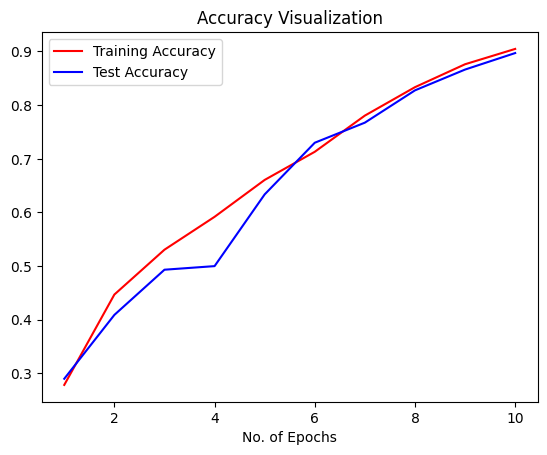

In [19]:
epochs = range(1, 11)
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Test Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Accuracy Visualization')
plt.legend()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step 
                        precision    recall  f1-score   support

               aphid_t       0.95      0.80      0.87        50
          black_rust_t       1.00      0.74      0.85        50
               blast_t       0.98      0.96      0.97        50
          brown_rust_t       0.75      0.80      0.78        50
     common_root_rot_t       0.82      0.98      0.89        50
fusarium_head_blight_t       0.96      0.94      0.95        50
             healthy_t       0.86      1.00      0.92        48
         leaf_blight_t       0.77      0.86      0.81        50
              mildew_t       0.98      0.84      0.90        50
                mite_t       0.81      0.84      0.82        50
            septoria_t       1.00      0.96      0.98        50
                smut_t       0.96      0.98      0.97        50
            stem_fly_t       0.98      0.94      0.96        50
            tan_spot_t       0.81      0.88      0.85        

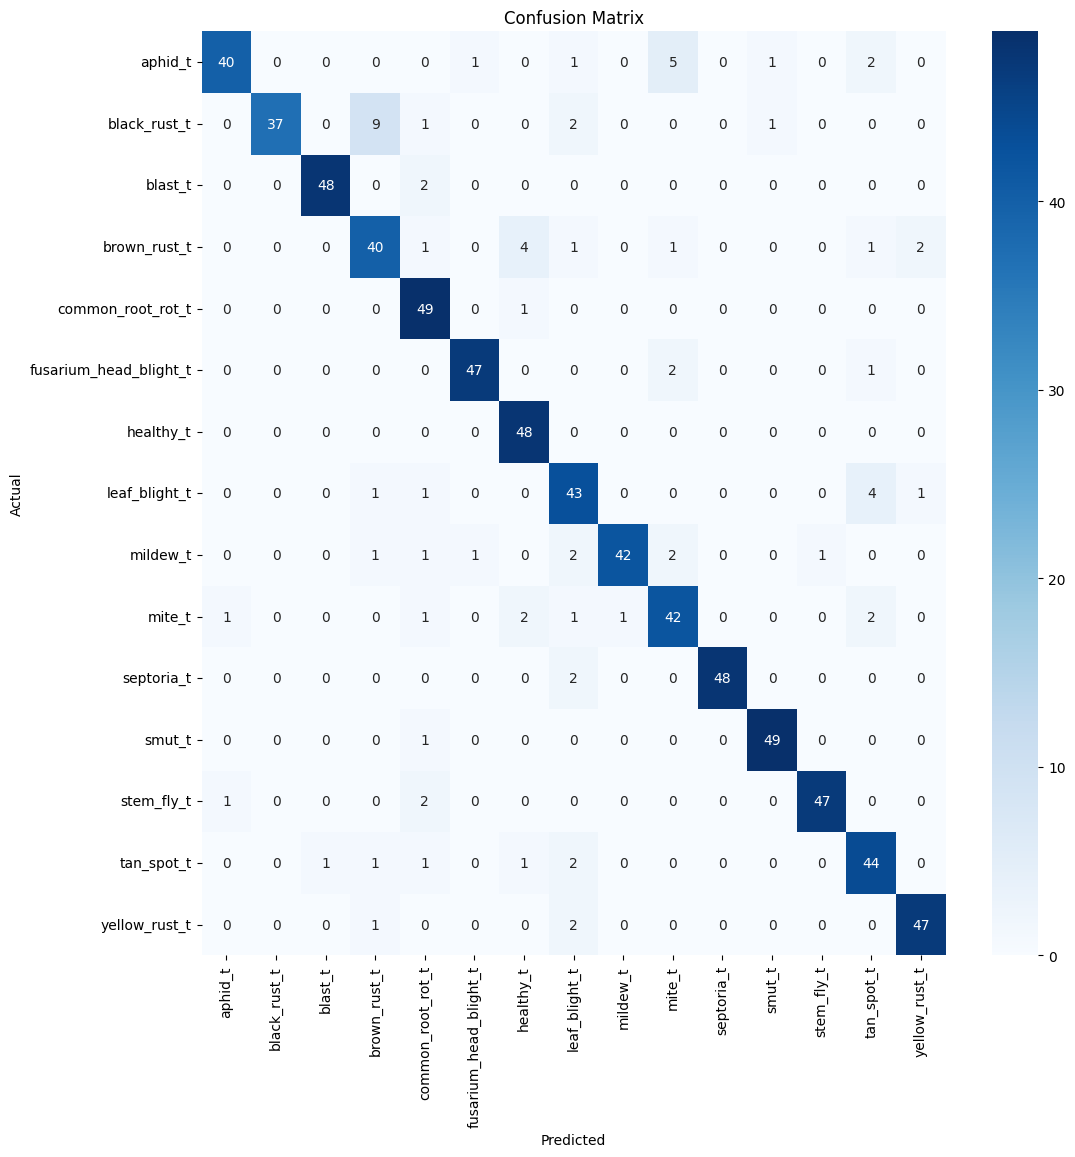

In [20]:
y_pred = cnn.predict(test_set)
predicted_categories = np.argmax(y_pred, axis=1)

true_categories = np.concatenate([y for x, y in test_set], axis=0)
Y_true = np.argmax(true_categories, axis=1)

cm = confusion_matrix(Y_true, predicted_categories)

print(classification_report(Y_true, predicted_categories, target_names=test_set.class_names))

plt.figure(figsize=(12, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_set.class_names, yticklabels=test_set.class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


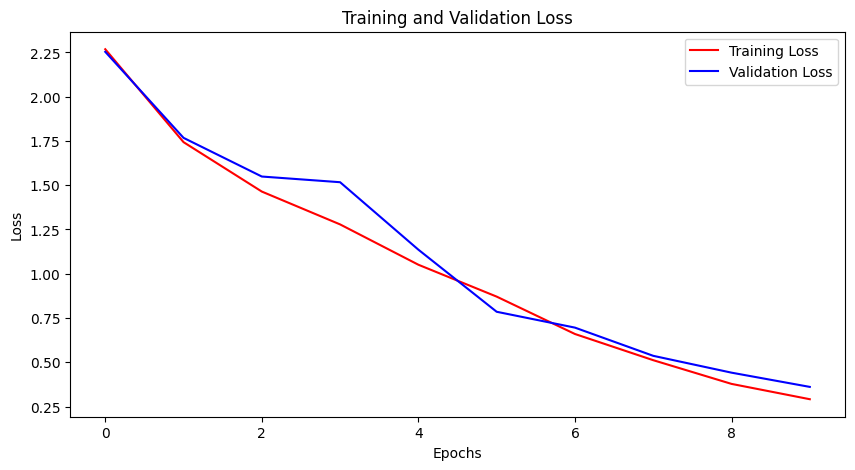

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

cnn = keras.models.load_model('trained_wheat_leaf_model.keras')

with open('training_hist.json', 'r') as f:
    training_history = json.load(f)

plt.figure(figsize=(10, 5))
plt.plot(training_history['loss'], color='red', label='Training Loss')
plt.plot(training_history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

Found 748 files belonging to 15 classes.
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step


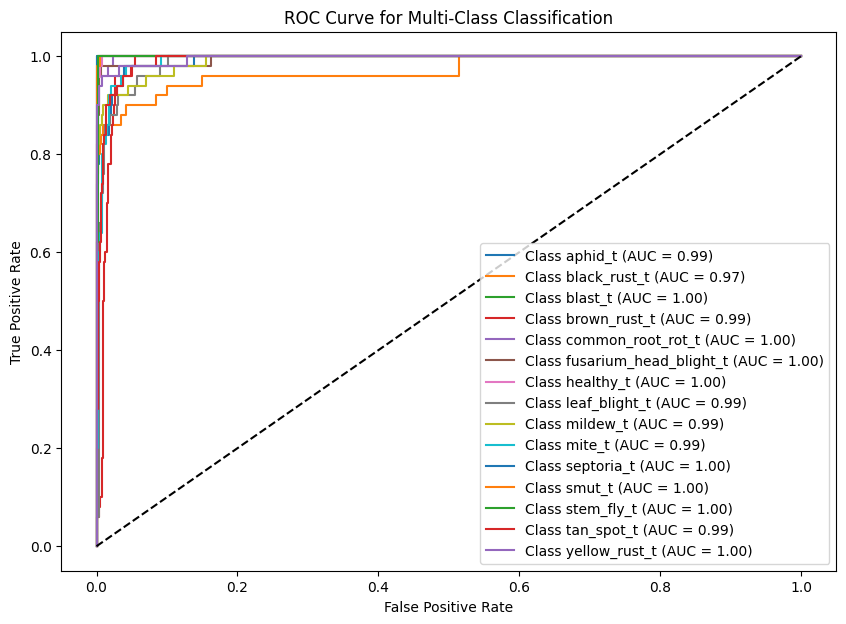

In [22]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

cnn = keras.models.load_model('trained_wheat_leaf_model.keras')

test_path = "C:\\Users\\Rahul Chauhan\\OneDrive\\Desktop\\ALL\\Project Dataset Wheat\\data\\test"
test_set = tf.keras.utils.image_dataset_from_directory(
    test_path, labels="inferred", label_mode="categorical",
    color_mode="rgb", batch_size=32, image_size=(128, 128), shuffle=False
)

true_labels = np.array([])
for images, labels in test_set:
    true_labels = np.concatenate([true_labels, np.argmax(labels.numpy(), axis=1)])

y_pred = cnn.predict(test_set)

n_classes = len(test_set.class_names)
true_labels_bin = label_binarize(true_labels, classes=range(n_classes))

plt.figure(figsize=(10, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(true_labels_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {test_set.class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Classification')
plt.legend()
plt.show()


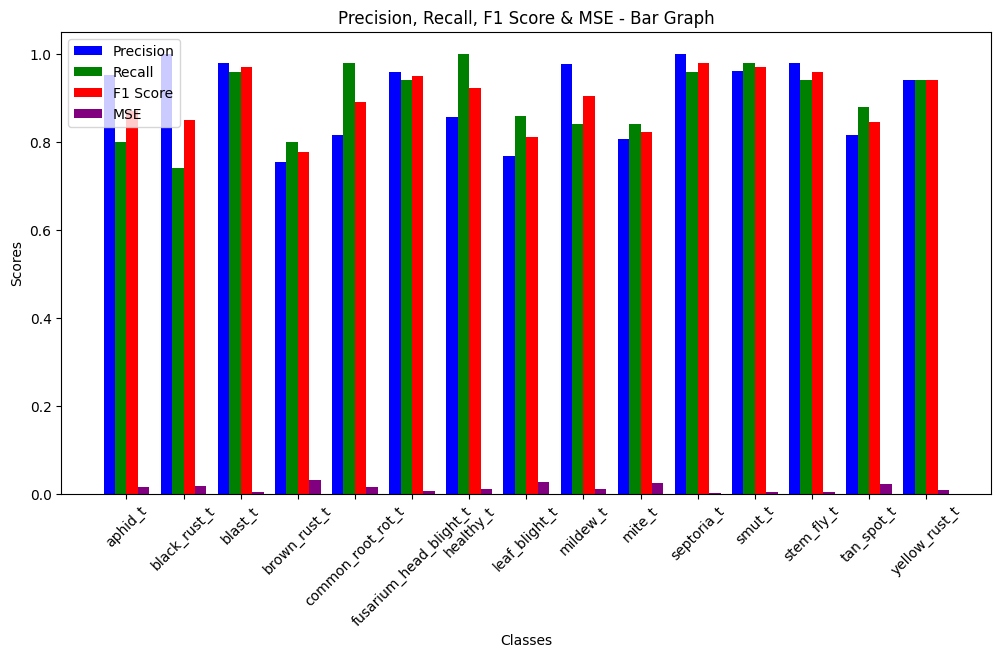

In [23]:
from sklearn.metrics import mean_squared_error

report = classification_report(Y_true, predicted_categories, target_names=test_set.class_names, output_dict=True)

precision = [report[label]['precision'] for label in test_set.class_names]
recall = [report[label]['recall'] for label in test_set.class_names]
f1_score = [report[label]['f1-score'] for label in test_set.class_names]

mse = [mean_squared_error((Y_true == i).astype(int), (predicted_categories == i).astype(int)) for i in range(len(test_set.class_names))]

x_labels = test_set.class_names
x = np.arange(len(x_labels)) 

plt.figure(figsize=(12, 6))
plt.bar(x - 0.3, precision, width=0.2, label='Precision', color='blue')
plt.bar(x - 0.1, recall, width=0.2, label='Recall', color='green')
plt.bar(x + 0.1, f1_score, width=0.2, label='F1 Score', color='red')
plt.bar(x + 0.3, mse, width=0.2, label='MSE', color='purple')

plt.xlabel('Classes')
plt.ylabel('Scores')
plt.title('Precision, Recall, F1 Score & MSE - Bar Graph')
plt.xticks(x, x_labels, rotation=45)
plt.legend()
plt.show()
